# GTSRB Traffic Sign Recognition

A CNN implementation for traffic sign recognition using the German Traffic Sign Recognition Benchmark (GTSRB) dataset.

## Features:
- CNN architecture optimized for traffic sign classification
- Data preprocessing and augmentation
- Model training with early stopping and learning rate reduction
- Real example testing with visualization
- Performance evaluation with Matthews Correlation Coefficient

## Dataset: GTSRB (43 traffic sign classes)

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from timeit import default_timer as timer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, matthews_corrcoef

# TensorFlow imports
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Clear any existing models and restart clean
tf.keras.backend.clear_session()

print("✅ Libraries imported successfully!")
print("🚀 Ready for traffic sign recognition training!")

✅ Libraries imported successfully!
🚀 Ready for traffic sign recognition training!


## 2. Data Loader Class

In [2]:
class GTSRBLoader:
    """GTSRB dataset loader for traffic sign recognition"""
    
    def __init__(self, data_path, img_size=80, samples_per_class=120):
        self.data_path = data_path
        self.img_size = img_size
        self.samples_per_class = samples_per_class
        self.num_classes = 43
        
    def load_dataset(self):
        """Load GTSRB dataset with preprocessing"""
        print(f"📊 Loading GTSRB dataset...")
        
        X, y = [], []
        train_path = os.path.join(self.data_path, "Train")
        
        if not os.path.exists(train_path):
            raise FileNotFoundError(f"Training data not found at {train_path}")
        
        for class_id in range(self.num_classes):
            class_path = os.path.join(train_path, str(class_id))
            if os.path.exists(class_path):
                files = [f for f in os.listdir(class_path) 
                        if f.lower().endswith(('.png', '.jpg', '.jpeg', '.ppm'))]
                
                files = files[:self.samples_per_class]
                
                for img_file in files:
                    img_path = os.path.join(class_path, img_file)
                    img = self._load_image(img_path)
                    if img is not None:
                        X.append(img)
                        y.append(class_id)
        
        X = np.array(X, dtype=np.float32)
        y = np.array(y, dtype=np.int32)
        
        print(f"✅ Dataset loaded: {len(X)} samples from {self.num_classes} classes")
        return X, y
    
    def _load_image(self, img_path):
        """Load and preprocess image"""
        try:
            img = cv2.imread(img_path)
            if img is None:
                return None
            
            img = cv2.resize(img, (self.img_size, self.img_size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 255.0
            
            return img
        except:
            return None

print("✅ GTSRB Loader class defined!")

✅ GTSRB Loader class defined!


## 3. Model Architecture

In [3]:
def create_traffic_sign_model(input_shape, num_classes=43):
    """Create CNN model for traffic sign recognition"""
    print(f"🏗️ Building CNN model for {num_classes} classes...")
    
    model = Sequential([
        # First block
        Conv2D(64, (5, 5), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Second block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.25),
        
        # Third block
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(2, 2),
        Dropout(0.3),
        
        # Classifier
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    print(f"✅ Model built! Parameters: {model.count_params():,}")
    return model

print("✅ Model creation function defined!")

✅ Model creation function defined!


## 4. Load and Prepare Data

In [4]:
# Configuration
DATA_PATH = "/Users/komalsaivulchi/Capstone/archive"
IMG_SIZE = 80
SAMPLES_PER_CLASS = 120
OUTPUT_DIR = "./experiment_output/"

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load data
print("🔄 Loading GTSRB dataset...")
loader = GTSRBLoader(DATA_PATH, img_size=IMG_SIZE, samples_per_class=SAMPLES_PER_CLASS)
X, y = loader.load_dataset()

# Split dataset
print("\n📊 Splitting dataset...")
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training: {len(X_train)} samples")
print(f"Validation: {len(X_val)} samples")  
print(f"Test: {len(X_test)} samples")

# Convert to categorical
y_train_cat = to_categorical(y_train, 43)
y_val_cat = to_categorical(y_val, 43)
y_test_cat = to_categorical(y_test, 43)

print("✅ Data prepared successfully!")

🔄 Loading GTSRB dataset...
📊 Loading GTSRB dataset...
✅ Dataset loaded: 5160 samples from 43 classes

📊 Splitting dataset...
Training: 3612 samples
Validation: 774 samples
Test: 774 samples
✅ Data prepared successfully!


## 5. Train Model

In [5]:
# Clear previous model
tf.keras.backend.clear_session()

# Create model
model = create_traffic_sign_model(X_train.shape[1:], num_classes=43)

# Training configuration
EPOCHS = 25
BATCH_SIZE = 32

# Callbacks
callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(patience=4, factor=0.5, min_lr=1e-7, monitor='val_accuracy'),
    ModelCheckpoint(f'{OUTPUT_DIR}/best_model.keras', save_best_only=True, monitor='val_accuracy')
]

print(f"🚀 Starting training...")
print(f"Epochs: {EPOCHS}, Batch size: {BATCH_SIZE}")

# Train model
start_time = timer()
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
end_time = timer()
training_time = end_time - start_time

print(f"\n✅ Training completed in {training_time:.1f} seconds")

🏗️ Building CNN model for 43 classes...
✅ Model built! Parameters: 14,282,091
🚀 Starting training...
Epochs: 25, Batch size: 32
Epoch 1/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 98s 857ms/step - accuracy: 0.1650 - loss: 3.4707 - val_accuracy: 0.1034 - val_loss: 3.2349 - learning_rate: 0.0010
Epoch 2/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 104s 924ms/step - accuracy: 0.8125 - loss: 0.6590 - val_accuracy: 0.3656 - val_loss: 2.1766 - learning_rate: 0.0010
Epoch 3/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 111s 985ms/step - accuracy: 0.9648 - loss: 0.1662 - val_accuracy: 0.6731 - val_loss: 1.1040 - learning_rate: 0.0010
Epoch 4/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 108s 957ms/step - accuracy: 0.9887 - loss: 0.0745 - val_accuracy: 0.9483 - val_loss: 0.2294 - learning_rate: 0.0010
Epoch 5/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 112s 993ms/step - accuracy: 0.9936 - loss: 0.0445 - val_accuracy: 0.9535 - val_loss: 0.1688 - learning_rate: 0.0010
Epoch 6/25
113/113 ━━━━━━━━━━━━━━━━━━━━ 114s 1s/step - accuracy: 0.9969 - loss: 0.0228 - val_

In [ ]:
# 5A. Report Training Accuracy (final and best)
if 'history' in globals() and hasattr(history, 'history'):
    acc_list = history.history.get('accuracy', [])
    if acc_list:
        final_train_acc = acc_list[-1]
        best_train_acc = max(acc_list)
        print(f"Final training accuracy: {final_train_acc:.4f}")
        print(f"Best training accuracy: {best_train_acc:.4f}")
    else:
        print("Training accuracy not found in history.")
else:
    print("No training history found. Run the training cell first.")

## 6. Evaluate Model

In [6]:
# Evaluate model
print("📊 Evaluating model performance...")

train_loss, train_acc = model.evaluate(X_train, y_train_cat, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val_cat, verbose=0)
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

# Get predictions for detailed metrics
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
test_mcc = matthews_corrcoef(y_test, y_pred_classes)

# Print results
print(f"\n🏆 RESULTS:")
print("=" * 40)
print(f"Training time: {training_time:.1f}s")
print(f"Test accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)")
print(f"Matthews MCC: {test_mcc:.4f}")
print(f"Training accuracy: {train_acc:.4f}")
print(f"Validation accuracy: {val_acc:.4f}")

# Performance verdict
if test_acc > 0.8:
    verdict = "🏆 EXCELLENT"
elif test_acc > 0.6:
    verdict = "🥈 GOOD"
else:
    verdict = "🥉 FAIR"

print(f"\nPerformance: {verdict}")

📊 Evaluating model performance...

🏆 RESULTS:
Training time: 2414.0s
Test accuracy: 0.9871 (98.7%)
Matthews MCC: 0.9868
Training accuracy: 1.0000
Validation accuracy: 0.9974

Performance: 🏆 EXCELLENT


## 7. Visualize Results

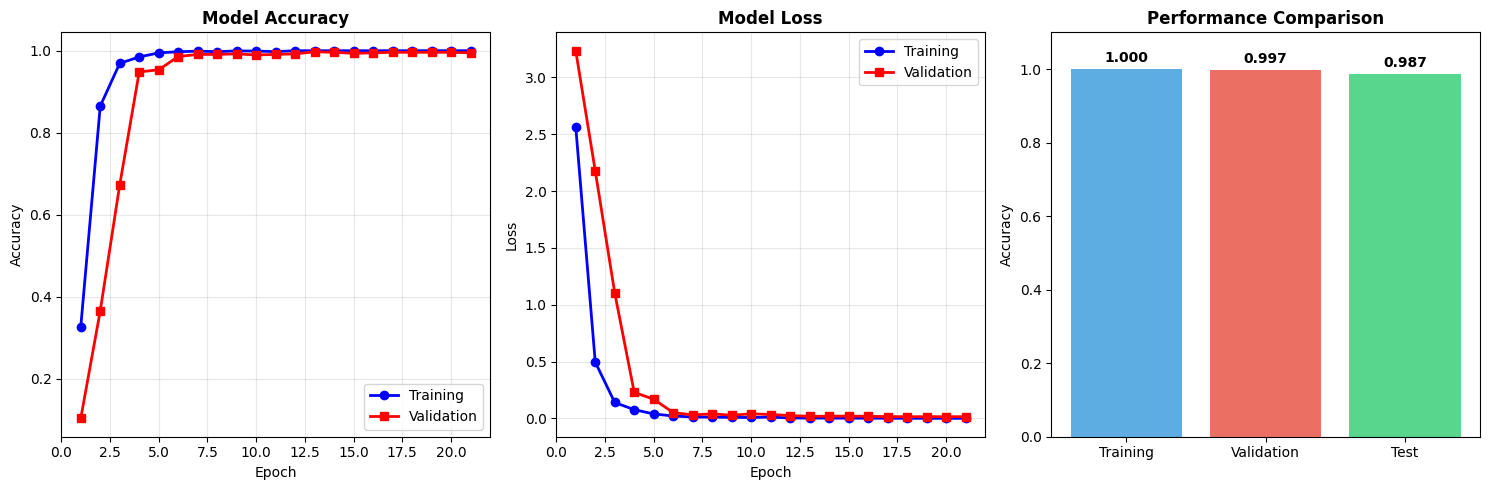

📊 Training visualizations saved!


In [7]:
# Plot training history
plt.figure(figsize=(15, 5))

# Accuracy plot
plt.subplot(1, 3, 1)
epochs = range(1, len(history.history['accuracy']) + 1)
plt.plot(epochs, history.history['accuracy'], 'b-', label='Training', linewidth=2, marker='o')
plt.plot(epochs, history.history['val_accuracy'], 'r-', label='Validation', linewidth=2, marker='s')
plt.title('Model Accuracy', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 3, 2)
plt.plot(epochs, history.history['loss'], 'b-', label='Training', linewidth=2, marker='o')
plt.plot(epochs, history.history['val_loss'], 'r-', label='Validation', linewidth=2, marker='s')
plt.title('Model Loss', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# Performance comparison
plt.subplot(1, 3, 3)
splits = ['Training', 'Validation', 'Test']
accuracies = [train_acc, val_acc, test_acc]
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = plt.bar(splits, accuracies, color=colors, alpha=0.8)
plt.title('Performance Comparison', fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, max(accuracies) * 1.1)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/training_results.png', dpi=200, bbox_inches='tight')
plt.show()

print("📊 Training visualizations saved!")

## 8. Save Model

In [8]:
# Save the trained model
model_path = f"{OUTPUT_DIR}/traffic_sign_model.keras"
model.save(model_path)
print(f"💾 Model saved to: {model_path}")

# Save training summary
summary_path = f"{OUTPUT_DIR}/training_summary.txt"
with open(summary_path, 'w') as f:
    f.write("GTSRB Traffic Sign Recognition - Training Summary\n")
    f.write("=" * 50 + "\n")
    f.write(f"Training time: {training_time:.1f} seconds\n")
    f.write(f"Test accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)\n")
    f.write(f"Matthews MCC: {test_mcc:.4f}\n")
    f.write(f"Training samples: {len(X_train)}\n")
    f.write(f"Test samples: {len(X_test)}\n")
    f.write(f"Model parameters: {model.count_params():,}\n")

print(f"📄 Summary saved to: {summary_path}")
print("✅ All results saved!")

💾 Model saved to: ./experiment_output//traffic_sign_model.keras
📄 Summary saved to: ./experiment_output//training_summary.txt
✅ All results saved!


## 9. Test with Real Examples

In [9]:
# GTSRB class names for interpretation
GTSRB_CLASSES = {
    0: 'Speed limit (20km/h)',
    1: 'Speed limit (30km/h)',
    2: 'Speed limit (50km/h)',
    3: 'Speed limit (60km/h)',
    4: 'Speed limit (70km/h)',
    5: 'Speed limit (80km/h)',
    6: 'End of speed limit (80km/h)',
    7: 'Speed limit (100km/h)',
    8: 'Speed limit (120km/h)',
    9: 'No passing',
    10: 'No passing for vehicles over 3.5 metric tons',
    11: 'Right-of-way at the next intersection',
    12: 'Priority road',
    13: 'Yield',
    14: 'Stop',
    15: 'No vehicles',
    16: 'Vehicles over 3.5 metric tons prohibited',
    17: 'No entry',
    18: 'General caution',
    19: 'Dangerous curve to the left',
    20: 'Dangerous curve to the right',
    21: 'Double curve',
    22: 'Bumpy road',
    23: 'Slippery road',
    24: 'Road narrows on the right',
    25: 'Road work',
    26: 'Traffic signals',
    27: 'Pedestrians',
    28: 'Children crossing',
    29: 'Bicycles crossing',
    30: 'Beware of ice/snow',
    31: 'Wild animals crossing',
    32: 'End of all speed and passing limits',
    33: 'Turn right ahead',
    34: 'Turn left ahead',
    35: 'Ahead only',
    36: 'Go straight or right',
    37: 'Go straight or left',
    38: 'Keep right',
    39: 'Keep left',
    40: 'Roundabout mandatory',
    41: 'End of no passing',
    42: 'End of no passing by vehicles over 3.5 metric tons'
}

def predict_traffic_sign(model, image, actual_class=None):
    """Predict traffic sign class for a single image"""
    # Ensure image is in correct format
    if len(image.shape) == 3:
        image = np.expand_dims(image, axis=0)
    
    # Get prediction
    prediction = model.predict(image, verbose=0)
    predicted_class = np.argmax(prediction[0])
    confidence = prediction[0][predicted_class]
    
    # Get class names
    predicted_name = GTSRB_CLASSES.get(predicted_class, f"Unknown ({predicted_class})")
    
    if actual_class is not None:
        actual_name = GTSRB_CLASSES.get(actual_class, f"Unknown ({actual_class})")
        is_correct = predicted_class == actual_class
        return predicted_class, predicted_name, confidence, is_correct, actual_name
    else:
        return predicted_class, predicted_name, confidence

print("🔮 Prediction function defined!")
print(f"📚 GTSRB has {len(GTSRB_CLASSES)} traffic sign classes")

🔮 Prediction function defined!
📚 GTSRB has 43 traffic sign classes


## 10. Real Example Predictions

🧪 Testing model with real examples from test set...
✅ Example 1:
  True: 28 - Children crossing
  Pred: 28 - Children crossing
  Confidence: 1.000 (High)

✅ Example 2:
  True:  4 - Speed limit (70km/h)
  Pred:  4 - Speed limit (70km/h)
  Confidence: 1.000 (High)

✅ Example 3:
  True: 29 - Bicycles crossing
  Pred: 29 - Bicycles crossing
  Confidence: 0.999 (High)

✅ Example 4:
  True: 20 - Dangerous curve to the right
  Pred: 20 - Dangerous curve to the right
  Confidence: 1.000 (High)

✅ Example 5:
  True:  3 - Speed limit (60km/h)
  Pred:  3 - Speed limit (60km/h)
  Confidence: 0.999 (High)

✅ Example 6:
  True: 25 - Road work
  Pred: 25 - Road work
  Confidence: 0.999 (High)

✅ Example 7:
  True: 14 - Stop
  Pred: 14 - Stop
  Confidence: 1.000 (High)

✅ Example 8:
  True: 27 - Pedestrians
  Pred: 27 - Pedestrians
  Confidence: 0.999 (High)

✅ Example 9:
  True: 18 - General caution
  Pred: 18 - General caution
  Confidence: 1.000 (High)

✅ Example 10:
  True: 13 - Yield
  Pred: 13 -

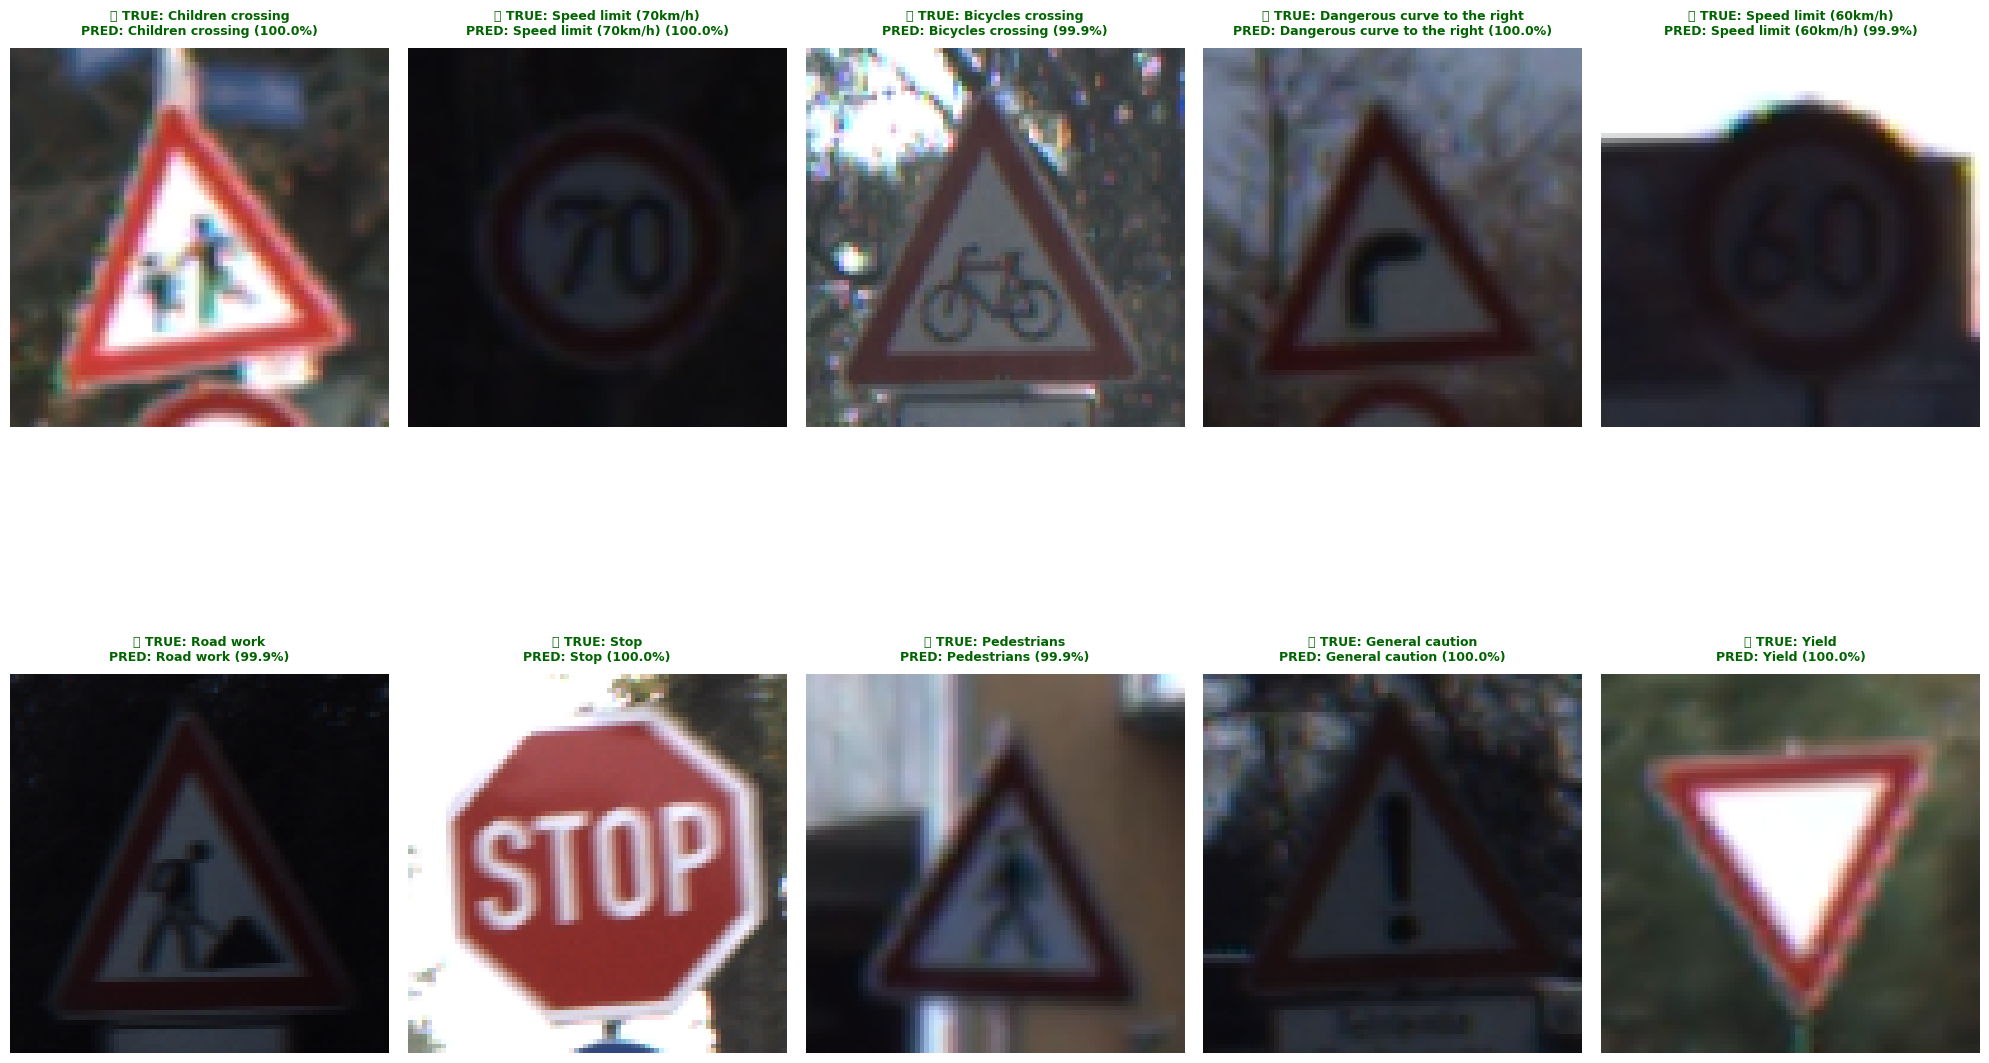

📊 REAL EXAMPLE RESULTS:
🎯 Sample accuracy: 100.0% (10/10)
🔥 High confidence rate: 100.0% (10/10)
📊 Average confidence: 1.000

🎉 EXCELLENT! Model performs very well on real examples!

💾 Enhanced visualization saved to: ./experiment_output//real_examples_enhanced.png


In [13]:
# Test with real examples from test set
print("🧪 Testing model with real examples from test set...")
print("=" * 60)

# Select random test samples
n_examples = 10
sample_indices = np.random.choice(len(X_test), n_examples, replace=False)

correct_predictions = 0
high_confidence_predictions = 0

# Create a list to store processed images
processed_images = []

# Create visualization with enhanced semi-transparent overlay
plt.figure(figsize=(20, 12))

for i, idx in enumerate(sample_indices):
    # Get image and true class
    test_image = X_test[idx]
    true_class = y_test[idx]
    
    # Make prediction
    pred_class, pred_name, confidence, is_correct, true_name = predict_traffic_sign(
        model, test_image, true_class
    )
    
    # Update counters
    if is_correct:
        correct_predictions += 1
    if confidence > 0.8:
        high_confidence_predictions += 1
    
    # Print result
    status = "✅" if is_correct else "❌"
    conf_level = "High" if confidence > 0.8 else "Med" if confidence > 0.5 else "Low"
    
    print(f"{status} Example {i+1}:")
    print(f"  True: {true_class:2d} - {true_name}")
    print(f"  Pred: {pred_class:2d} - {pred_name}")
    print(f"  Confidence: {confidence:.3f} ({conf_level})")
    print()
    
    # Display clean image without any overlay
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_image)
    
    # Enhanced title with both prediction and true class information
    title_color = 'darkgreen' if is_correct else 'darkred'
    title_text = f"{status} TRUE: {true_name}\nPRED: {pred_name} ({confidence*100:.1f}%)"
    
    plt.title(title_text, fontsize=9, color=title_color, fontweight='bold', pad=10)
    plt.axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.05, hspace=0.15)  # Adjusted spacing for titles
plt.savefig(f'{OUTPUT_DIR}/real_examples_enhanced.png', dpi=200, bbox_inches='tight')
plt.show()

# Summary statistics
sample_accuracy = correct_predictions / n_examples
high_conf_rate = high_confidence_predictions / n_examples

print("📊 REAL EXAMPLE RESULTS:")
print("=" * 40)
print(f"🎯 Sample accuracy: {sample_accuracy:.1%} ({correct_predictions}/{n_examples})")
print(f"🔥 High confidence rate: {high_conf_rate:.1%} ({high_confidence_predictions}/{n_examples})")
print(f"📊 Average confidence: {np.mean([predict_traffic_sign(model, X_test[idx])[2] for idx in sample_indices]):.3f}")

if sample_accuracy >= 0.8:
    print("\n🎉 EXCELLENT! Model performs very well on real examples!")
elif sample_accuracy >= 0.6:
    print("\n👍 GOOD! Model shows solid performance on real examples!")
else:
    print("\n⚠️ Model needs improvement for better real-world performance.")

print(f"\n💾 Enhanced visualization saved to: {OUTPUT_DIR}/real_examples_enhanced.png")